# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [5]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [6]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [7]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [8]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [9]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

In [16]:
# Зафиксируем зерно, для воспроизводимости результата
torch.manual_seed(42)
np.random.seed(42)

In [11]:
# Здесь создаём базовую RNN-модель почти как в семинаре
class CharLM(nn.Module):
    def __init__(
        self,
        hidden_dim: int,
        vocab_size: int,
        num_classes: int = 4,
        aggregation_type: str = 'max'
    ):
        super().__init__()

        # Здесь превращаем индексы слов в векторы
        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        # Здесь используем обычную RNN из семинара
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)

        # Здесь делаем небольшую нелинейную голову перед классификацией
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        # Здесь выбираем способ агрегации по времени
        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        # Здесь получаем эмбеддинги слов
        embeddings = self.embedding(input_batch)

        # Здесь прогоняем последовательность через RNN
        output, _ = self.rnn(embeddings)

        # Здесь агрегируем выходы RNN в один вектор текста
        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        # Здесь делаем финальное преобразование перед классификацией
        output = self.dropout(self.linear(self.non_lin(output)))
        prediction = self.projection(self.non_lin(output))

        return prediction

In [12]:
# Здесь пишем простой цикл обучения одной модели
def train_model(
    model,
    train_dataloader,
    eval_dataloader,
    num_epochs=5,
    lr=1e-3
):
    # Здесь используем обычную функцию потерь для многоклассовой классификации
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    eval_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []

        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
            # Здесь переносим батч на нужное устройство
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            # Здесь делаем шаг обучения
            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        # Здесь считаем средний loss за эпоху
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(avg_loss)

        # Здесь используем готовую функцию evaluate из ноутбука
        acc = evaluate(model, eval_dataloader)
        eval_accuracies.append(acc)

        print(f"Эпоха {epoch + 1}: loss = {avg_loss:.4f}, eval_accuracy = {acc:.4f}")

    return train_losses, eval_accuracies

In [13]:
# Здесь задаём основные параметры baseline
num_epochs = 5
hidden_dim = 256

losses_type = {}
acc_type = {}
models = {}

# Здесь обучаем две версии модели: с max и mean агрегацией
for aggregation_type in ["max", "mean"]:
    print(f"\nОбучаем модель с aggregation_type = {aggregation_type}")

    model = CharLM(
        hidden_dim=hidden_dim,
        vocab_size=len(vocab),
        num_classes=4,
        aggregation_type=aggregation_type
    ).to(device)

    losses, acc = train_model(
        model=model,
        train_dataloader=train_dataloader,
        eval_dataloader=eval_dataloader,
        num_epochs=num_epochs,
        lr=1e-3
    )

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc
    models[aggregation_type] = model


Обучаем модель с aggregation_type = max


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 1: loss = 0.4026, eval_accuracy = 0.8854


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 2: loss = 0.2790, eval_accuracy = 0.9022


...

Эпоха 3: loss = 0.2151, eval_accuracy = 0.9002


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 4: loss = 0.1842, eval_accuracy = 0.9068


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 5: loss = 0.1619, eval_accuracy = 0.9002


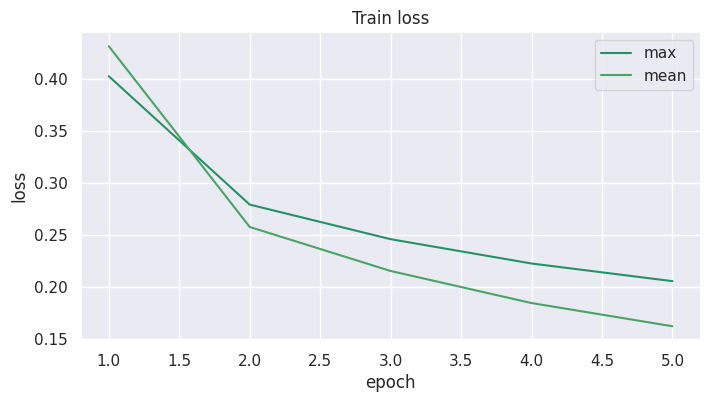

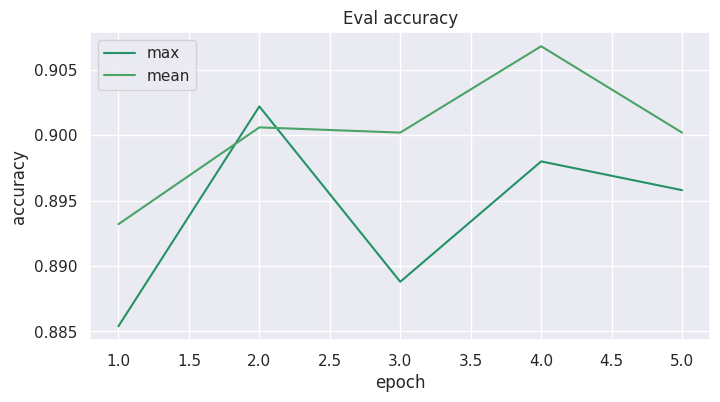

In [14]:
# Здесь строим график train loss
plt.figure(figsize=(8, 4))
for name, values in losses_type.items():
    plt.plot(range(1, len(values) + 1), values, label=name)

plt.title("Train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()


# Здесь строим график eval accuracy
plt.figure(figsize=(8, 4))
for name, values in acc_type.items():
    plt.plot(range(1, len(values) + 1), values, label=name)

plt.title("Eval accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Здесь выбираем лучший baseline по accuracy
best_aggregation = max(acc_type, key=lambda name: max(acc_type[name]))
best_score = max(acc_type[best_aggregation])
best_model = models[best_aggregation]

print("Лучший baseline:", best_aggregation)
print(f"Лучший baseline accuracy: {best_score:.4f}")

Лучший baseline: mean
Лучший baseline accuracy: 0.9068


Удалось воспроизвести работу модели из семинара но уже при классификации на 4 раздела. В базовой реализации train loss монотонно уменьшается у обеих моделей, но mean ведёт себя более стабильно. Обе модели дали схожие результаты, соответствующие одному баллу.

## Эксперимент 1, меняем RNN на GRU

В остальном оставляем всё, как в предыдущем эксперименте, но проверять будем только с aggregation_type='mean', который показал лучший результат ранее.

In [17]:
# Здесь создаём модель GRU вместо обычной RNN
class GRUClassifier(nn.Module):
    def __init__(
        self,
        hidden_dim: int,
        vocab_size: int,
        num_classes: int = 4,
        aggregation_type: str = 'mean'
    ):
        super().__init__()

        # Здесь превращаем индексы слов в векторы
        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        # Здесь заменяем RNN на GRU
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        # Здесь оставляем ту же классификационную голову
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        # Здесь оставляем тот же способ агрегации
        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        # Здесь получаем эмбеддинги слов
        embeddings = self.embedding(input_batch)

        # Здесь прогоняем последовательность через GRU
        output, _ = self.rnn(embeddings)

        # Здесь агрегируем выходы по времени
        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        # Здесь делаем финальную классификацию
        output = self.dropout(self.linear(self.non_lin(output)))
        prediction = self.projection(self.non_lin(output))

        return prediction

In [18]:
# Здесь задаём те же параметры, что и у baseline
gru_hidden_dim = 256
gru_num_epochs = 5
gru_aggregation_type = "mean"

# Здесь создаём и обучаем GRU-модель
gru_model = GRUClassifier(
    hidden_dim=gru_hidden_dim,
    vocab_size=len(vocab),
    num_classes=4,
    aggregation_type=gru_aggregation_type
).to(device)

gru_losses, gru_acc = train_model(
    model=gru_model,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    num_epochs=gru_num_epochs,
    lr=1e-3
)

Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 1: loss = 0.3665, eval_accuracy = 0.9024


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 2: loss = 0.2093, eval_accuracy = 0.9174


Epoch 3/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 3: loss = 0.1448, eval_accuracy = 0.9090


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 4: loss = 0.0960, eval_accuracy = 0.9056


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 5: loss = 0.0691, eval_accuracy = 0.9080


In [19]:
# Здесь выводим лучший результат GRU
best_gru_score = max(gru_acc)

print("Лучший результат GRU:", f"{best_gru_score:.4f}")

Лучший результат GRU: 0.9174


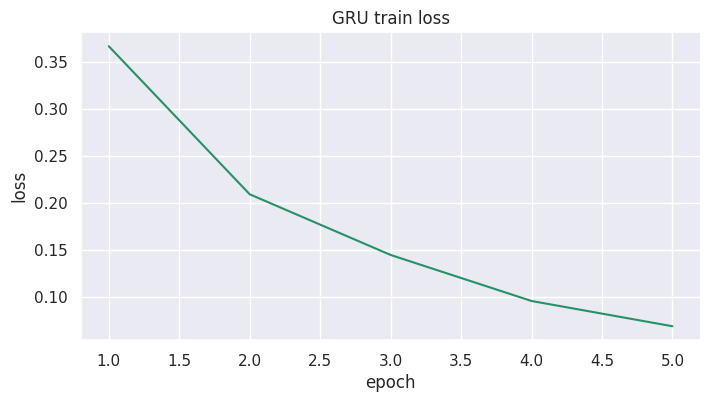

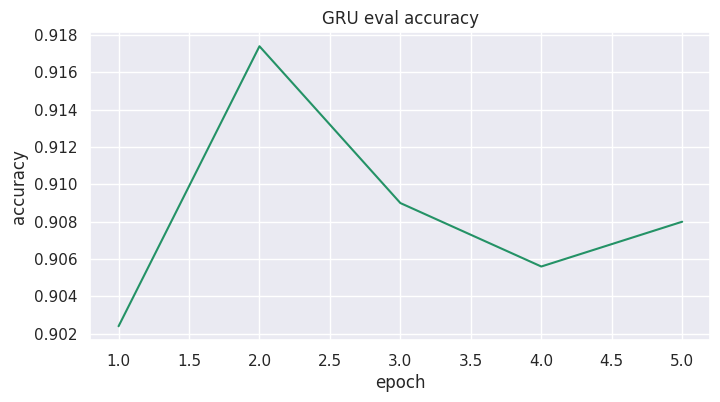

In [21]:
# Здесь строим график train loss для GRU
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(gru_losses) + 1), gru_losses)
plt.title("GRU train loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.show()


# Здесь строим график eval accuracy для GRU
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(gru_acc) + 1), gru_acc)
plt.title("GRU eval accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid(True)
plt.show()

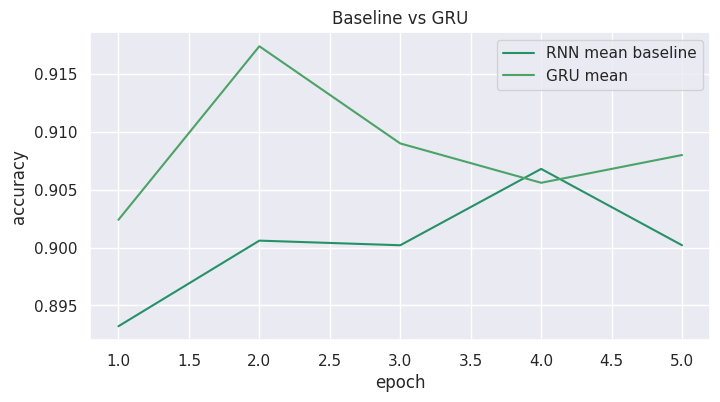

In [22]:
# Здесь сравниваем accuracy baseline и GRU по эпохам
plt.figure(figsize=(8, 4))

plt.plot(range(1, len(acc_type["mean"]) + 1), acc_type["mean"], label="RNN mean baseline")
plt.plot(range(1, len(gru_acc) + 1), gru_acc, label="GRU mean")

plt.title("Baseline vs GRU")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

##

## Эксперимент 2, подбор гиперпараметров для GRU-модели

Оставляем предыдущую модель, но делаем перебор нескольких вариантов гиперпараметров, смотрим, будут ли они влиять на результат.

In [23]:
# Создаём компактную GRU-модель для подбора гиперпараметров
class TunedGRUClassifier(nn.Module):
    def __init__(
        self,
        hidden_dim,
        vocab_size,
        num_classes=4,
        aggregation_type="mean",
        dropout_rate=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(dropout_rate)
        self.aggregation_type = aggregation_type

    def forward(self, input_batch):
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)

        if self.aggregation_type == "max":
            output = output.max(dim=1)[0]
        elif self.aggregation_type == "mean":
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))
        prediction = self.projection(self.non_lin(output))
        return prediction


Запуск: gru_h384_lr1e3


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 1: loss = 0.3506, eval_accuracy = 0.9012


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 2: loss = 0.1998, eval_accuracy = 0.9120


...

Эпоха 3: loss = 0.1278, eval_accuracy = 0.9138


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 4: loss = 0.0729, eval_accuracy = 0.9046


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 5: loss = 0.0480, eval_accuracy = 0.9030

Итоги:
gru_h384_lr1e3 -> 0.9120
gru_h512_lr1e3 -> 0.9120
gru_h512_lr5e4 -> 0.9138

Лучшая конфигурация: gru_h512_lr5e4
Лучший accuracy: 0.9138


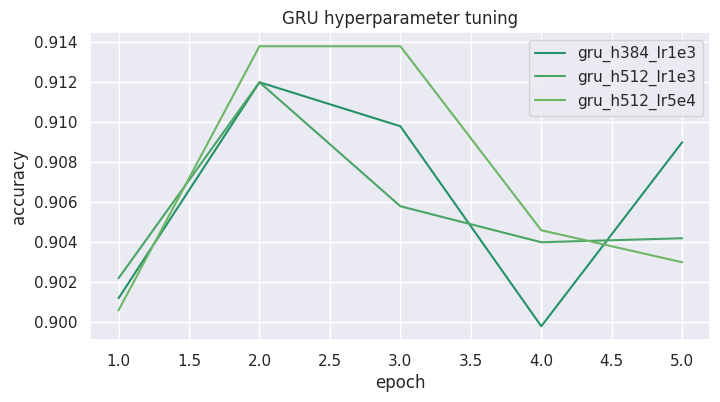

In [24]:
# Запускаем несколько конфигураций GRU и сравниваем их
configs = [
    {"name": "gru_h384_lr1e3", "hidden_dim": 384, "lr": 1e-3, "dropout_rate": 0.1},
    {"name": "gru_h512_lr1e3", "hidden_dim": 512, "lr": 1e-3, "dropout_rate": 0.1},
    {"name": "gru_h512_lr5e4", "hidden_dim": 512, "lr": 5e-4, "dropout_rate": 0.1},
]

tuned_results = {}
best_model = None
best_name = None
best_score = -1

for cfg in configs:
    print(f"\nЗапуск: {cfg['name']}")

    model = TunedGRUClassifier(
        hidden_dim=cfg["hidden_dim"],
        vocab_size=len(vocab),
        num_classes=4,
        aggregation_type="mean",
        dropout_rate=cfg["dropout_rate"]
    ).to(device)

    losses, acc = train_model(
        model=model,
        train_dataloader=train_dataloader,
        eval_dataloader=eval_dataloader,
        num_epochs=5,
        lr=cfg["lr"]
    )

    tuned_results[cfg["name"]] = {
        "losses": losses,
        "acc": acc,
        "best_acc": max(acc),
    }

    if max(acc) > best_score:
        best_score = max(acc)
        best_name = cfg["name"]
        best_model = model

print("\nИтоги:")
for name, result in tuned_results.items():
    print(name, "->", f"{result['best_acc']:.4f}")

print("\nЛучшая конфигурация:", best_name)
print("Лучший accuracy:", f"{best_score:.4f}")

plt.figure(figsize=(8, 4))
for name, result in tuned_results.items():
    plt.plot(range(1, len(result["acc"]) + 1), result["acc"], label=name)

plt.title("GRU hyperparameter tuning")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Эксперимент 3. Сравнение модели с 1 или 2 рекуррентными слоями

ради интереса попробую ещё и изменить количество слоёв модели. Возможно архитектурное изменение даст лучший эффект?

In [25]:
# Создаём GRU-модель, в которой можно менять число рекуррентных слоёв
class MultiLayerGRUClassifier(nn.Module):
    def __init__(
        self,
        hidden_dim,
        vocab_size,
        num_classes=4,
        aggregation_type="mean",
        dropout_rate=0.1,
        num_layers=1
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim)

        self.rnn = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0
        )

        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(dropout_rate)
        self.aggregation_type = aggregation_type

    def forward(self, input_batch):
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)

        if self.aggregation_type == "max":
            output = output.max(dim=1)[0]
        elif self.aggregation_type == "mean":
            output = output.mean(dim=1)
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))
        prediction = self.projection(self.non_lin(output))

        return prediction

In [26]:
# Сравниваем однослойную и двухслойную GRU
layer_configs = [
    {"name": "gru_1_layer", "num_layers": 1},
    {"name": "gru_2_layers", "num_layers": 2},
]

layer_results = {}
best_layer_model = None
best_layer_name = None
best_layer_score = -1

for cfg in layer_configs:
    print(f"\nЗапуск: {cfg['name']}")

    model = MultiLayerGRUClassifier(
        hidden_dim=256,
        vocab_size=len(vocab),
        num_classes=4,
        aggregation_type="mean",
        dropout_rate=0.1,
        num_layers=cfg["num_layers"]
    ).to(device)

    losses, acc = train_model(
        model=model,
        train_dataloader=train_dataloader,
        eval_dataloader=eval_dataloader,
        num_epochs=5,
        lr=1e-3
    )

    layer_results[cfg["name"]] = {
        "losses": losses,
        "acc": acc,
        "best_acc": max(acc),
    }

    if max(acc) > best_layer_score:
        best_layer_score = max(acc)
        best_layer_name = cfg["name"]
        best_layer_model = model

print("\nИтоги:")
for name, result in layer_results.items():
    print(name, "->", f"{result['best_acc']:.4f}")

print("\nЛучшая конфигурация:", best_layer_name)
print("Лучший accuracy:", f"{best_layer_score:.4f}")


Запуск: gru_1_layer


Epoch 1/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 1: loss = 0.3665, eval_accuracy = 0.8966


Epoch 2/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 2: loss = 0.2095, eval_accuracy = 0.9124


...

Эпоха 3: loss = 0.1571, eval_accuracy = 0.9110


Epoch 4/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 4: loss = 0.1107, eval_accuracy = 0.9132


Epoch 5/5:   0%|          | 0/3750 [00:00<?, ?it/s]

Эпоха 5: loss = 0.0842, eval_accuracy = 0.9046

Итоги:
gru_1_layer -> 0.9124
gru_2_layers -> 0.9132

Лучшая конфигурация: gru_2_layers
Лучший accuracy: 0.9132


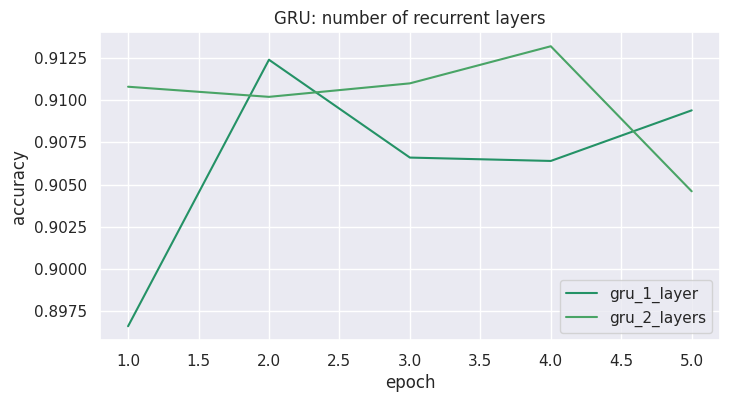

In [27]:
# Сравниваем качество однослойной и двухслойной GRU по эпохам
plt.figure(figsize=(8, 4))

for name, result in layer_results.items():
    plt.plot(range(1, len(result["acc"]) + 1), result["acc"], label=name)

plt.title("GRU: number of recurrent layers")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Выводы по экспериментам

В первом эксперименте менялся только тип рекуррентного слоя: обычная RNN модель была заменена на GRU при сохранении остальных параметров модели. Замена RNN на GRU улучшила качество модели: лучший accuracy вырос с 0.9068 до 0.9174, что достаточно для максимального балла. При этом наилучший результат был достигнут уже на 2-й эпохе, после чего качество на валидации снизилось, несмотря на дальнейшее уменьшение train loss, что может говорить о начале переобучения модели.

Во втором эксперименте был выполнен подбор гиперпараметров для модели GRU. Были проверены конфигурации с увеличенной размерностью скрытого состояния (384 и 512) и с уменьшенным learning rate. Лучший результат второго эксперимента составил 0.9138 для конфигурации hidden_dim=512, lr=5e-4. Однако этот результат оказался ниже, чем у исходной GRU-модели из первого эксперимента (0.9174).
Это показывает, что простое увеличение размера модели и изменение скорости обучения не гарантируют улучшения качества. Наиболее удачным изменением в работе оказалась именно замена RNN на GRU, а не дальнейшее наращивание ёмкости модели.

В третьем эксперименте менялось только число слоёв: увеличение числа рекуррентных слоёв с 1 до 2 дало лишь минимальный прирост, похожий на статистическую погрешность и результат всё равно оказался хуже лучшей однослойной GRU, полученной в первом эксперименте.
При этом время обучения модели выросло гораздо заметнее, на десятки процентов. Тем не менее, двухслойная GRU также показала высокий результат — 0.9132.

# Финальный результат

Наиболее результативной моделью оказалась однослойная GRU с hidden_dim=256, aggregation_type='mean' и lr=1e-3, показавшая лучший accuracy = **0.9174**